In [33]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

train = pd.read_csv('./generated/competition_train.csv')
test = pd.read_csv('./generated/competition_test.csv')

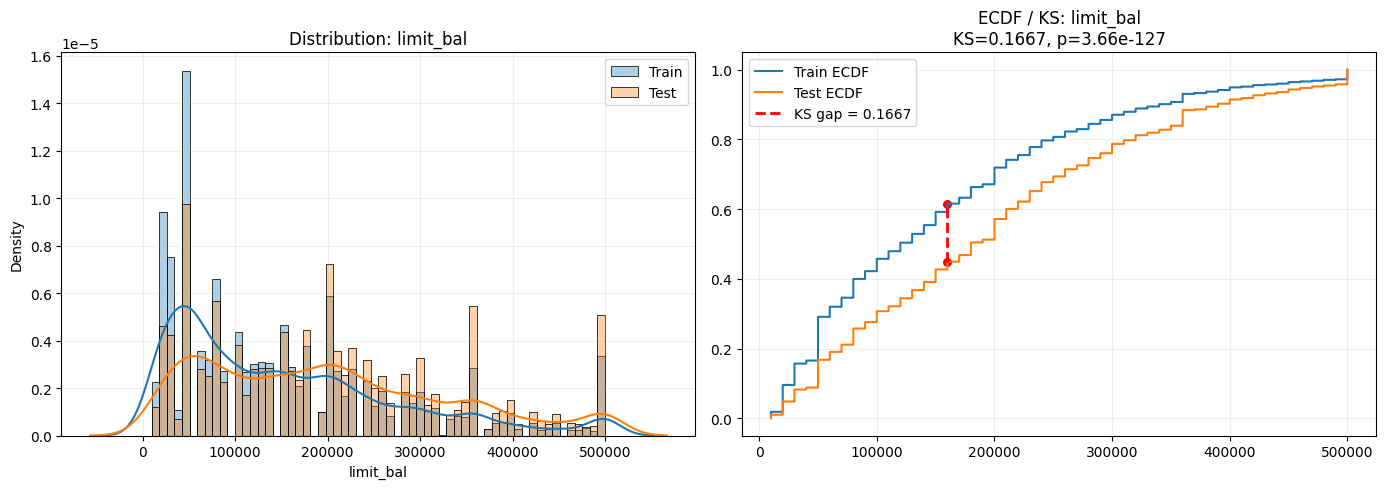

Feature: limit_bal
  KS statistic : 0.166736
  p-value      : 3.658910e-127
  Max gap at x : 160000.000000
  Train CDF    : 0.615935
  Test CDF     : 0.449199
------------------------------------------------------------


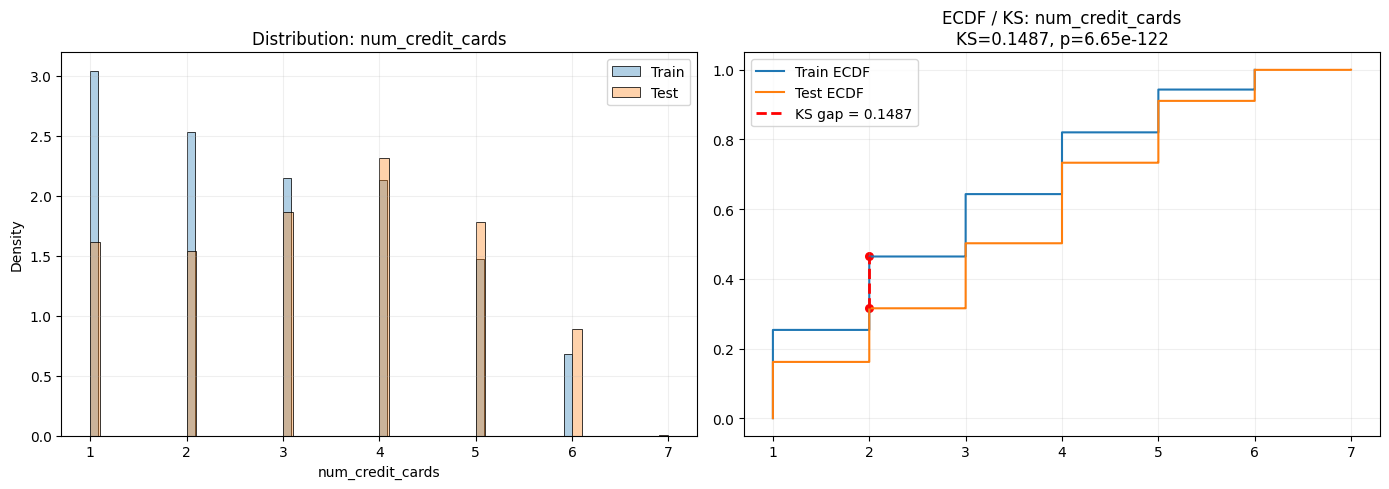

Feature: num_credit_cards
  KS statistic : 0.148673
  p-value      : 6.653603e-122
  Max gap at x : 2.000000
  Train CDF    : 0.464123
  Test CDF     : 0.315450
------------------------------------------------------------


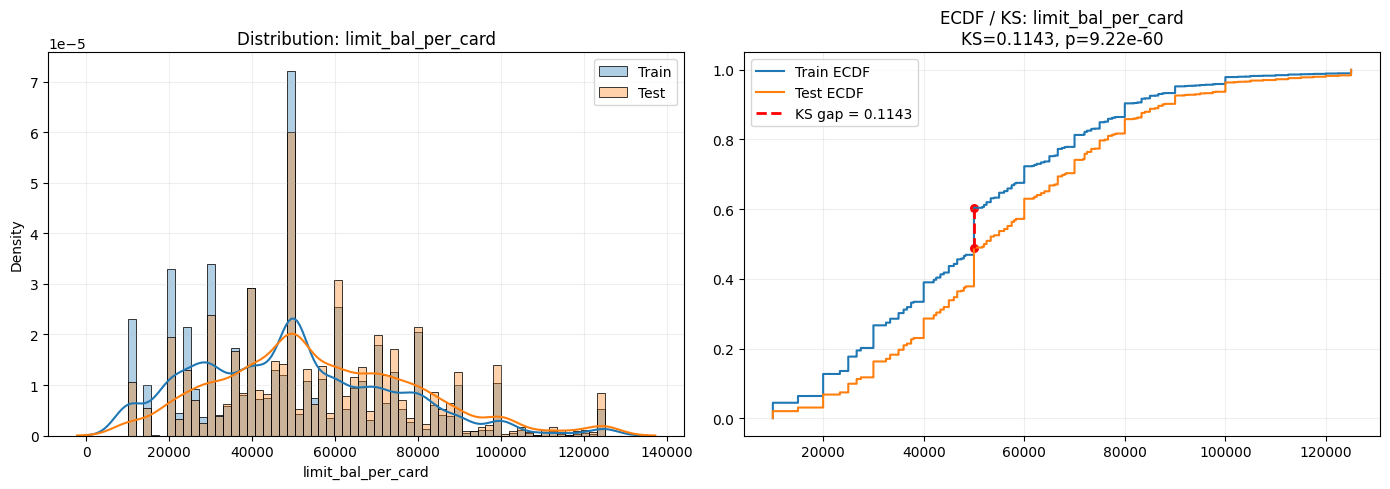

Feature: limit_bal_per_card
  KS statistic : 0.114267
  p-value      : 9.224807e-60
  Max gap at x : 50000.000000
  Train CDF    : 0.603972
  Test CDF     : 0.489705
------------------------------------------------------------


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# ------------------------------------------------------------
# Optional: if train/test are not yet cleaned
# train = clean_data(train, assumption=True)
# test = clean_data(test, assumption=True)
# ------------------------------------------------------------

train_plot = train.copy()
test_plot = test.copy()

# Safe engineered feature
train_plot["limit_bal_per_card"] = train_plot["limit_bal"] / train_plot["num_credit_cards"].replace(0, np.nan)
test_plot["limit_bal_per_card"] = test_plot["limit_bal"] / test_plot["num_credit_cards"].replace(0, np.nan)


def ecdf_values(x):
    """Return sorted x and empirical CDF values."""
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def ks_details(train_series, test_series):
    """Compute KS statistic and approximate location of max ECDF gap."""
    tr = train_series.dropna().values
    te = test_series.dropna().values

    ks = ks_2samp(tr, te)

    # Build common grid from observed values
    grid = np.sort(np.unique(np.concatenate([tr, te])))

    tr_sorted = np.sort(tr)
    te_sorted = np.sort(te)

    tr_cdf = np.searchsorted(tr_sorted, grid, side="right") / len(tr_sorted)
    te_cdf = np.searchsorted(te_sorted, grid, side="right") / len(te_sorted)

    abs_diff = np.abs(tr_cdf - te_cdf)
    idx = np.argmax(abs_diff)

    return {
        "ks_stat": ks.statistic,
        "pvalue": ks.pvalue,
        "x_at_max_gap": grid[idx],
        "train_cdf_at_gap": tr_cdf[idx],
        "test_cdf_at_gap": te_cdf[idx],
    }


def plot_ks_feature(train_df, test_df, feature, clip_quantiles=None, bins=60):
    """
    Plot train/test distribution and ECDF for one feature.
    
    Parameters
    ----------
    clip_quantiles : tuple or None
        Example: (0.01, 0.99) to zoom in for heavy-tailed variables.
    """
    tr = train_df[feature].copy()
    te = test_df[feature].copy()

    if clip_quantiles is not None:
        q_low = min(tr.quantile(clip_quantiles[0]), te.quantile(clip_quantiles[0]))
        q_high = max(tr.quantile(clip_quantiles[1]), te.quantile(clip_quantiles[1]))
        tr = tr.clip(q_low, q_high)
        te = te.clip(q_low, q_high)

    stats = ks_details(tr, te)

    tr_ecdf_x, tr_ecdf_y = ecdf_values(tr)
    te_ecdf_x, te_ecdf_y = ecdf_values(te)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: histogram / density
    sns.histplot(tr.dropna(), stat="density", bins=bins, color="tab:blue", alpha=0.35,
                 label="Train", ax=axes[0])
    sns.histplot(te.dropna(), stat="density", bins=bins, color="tab:orange", alpha=0.35,
                 label="Test", ax=axes[0])

    # KDE can be useful but may be unstable for discrete vars like num_credit_cards
    # We'll only add KDE if there are enough unique values
    if tr.nunique(dropna=True) > 10 and te.nunique(dropna=True) > 10:
        sns.kdeplot(tr.dropna(), color="tab:blue", ax=axes[0])
        sns.kdeplot(te.dropna(), color="tab:orange", ax=axes[0])

    axes[0].set_title(f"Distribution: {feature}")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    # Right: ECDFs
    axes[1].step(tr_ecdf_x, tr_ecdf_y, where="post", color="tab:blue", label="Train ECDF")
    axes[1].step(te_ecdf_x, te_ecdf_y, where="post", color="tab:orange", label="Test ECDF")

    # Mark KS max gap
    x0 = stats["x_at_max_gap"]
    y1 = stats["train_cdf_at_gap"]
    y2 = stats["test_cdf_at_gap"]

    axes[1].vlines(x0, min(y1, y2), max(y1, y2), color="red", linestyle="--", linewidth=2,
                   label=f"KS gap = {stats['ks_stat']:.4f}")
    axes[1].scatter([x0, x0], [y1, y2], color="red", s=30)

    axes[1].set_title(
        f"ECDF / KS: {feature}\nKS={stats['ks_stat']:.4f}, p={stats['pvalue']:.2e}"
    )
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    print(f"Feature: {feature}")
    print(f"  KS statistic : {stats['ks_stat']:.6f}")
    print(f"  p-value      : {stats['pvalue']:.6e}")
    print(f"  Max gap at x : {stats['x_at_max_gap']:.6f}")
    print(f"  Train CDF    : {stats['train_cdf_at_gap']:.6f}")
    print(f"  Test CDF     : {stats['test_cdf_at_gap']:.6f}")
    print("-" * 60)


# ------------------------------------------------------------
# Plot requested features
# ------------------------------------------------------------

plot_ks_feature(train_plot, test_plot, "limit_bal", clip_quantiles=(0.01, 0.99))
plot_ks_feature(train_plot, test_plot, "num_credit_cards")
plot_ks_feature(train_plot, test_plot, "limit_bal_per_card", clip_quantiles=(0.01, 0.99))

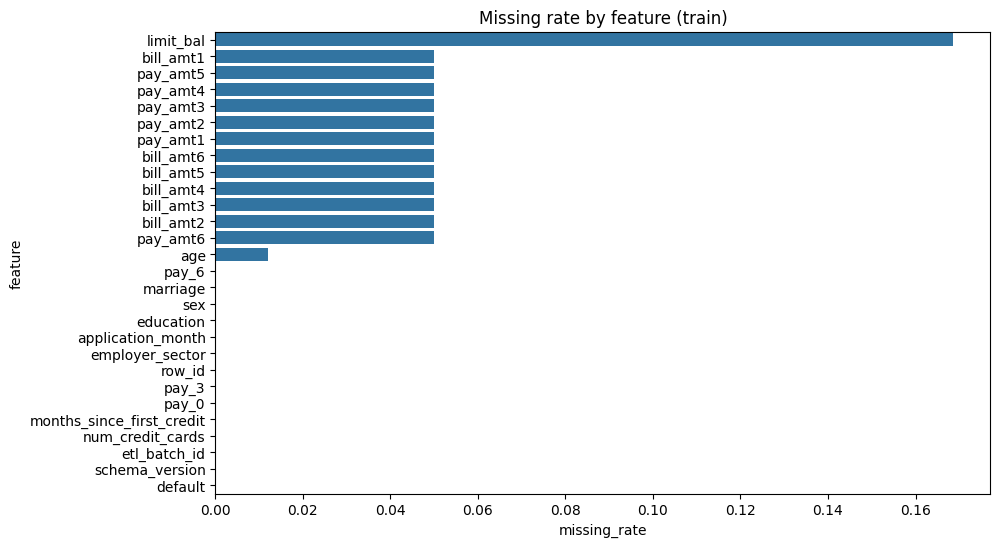

In [15]:
missing_summary = (
    train.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "feature"})
)

plt.figure(figsize=(10, 6))
sns.barplot(data=missing_summary, x="missing_rate", y="feature")
plt.title("Missing rate by feature (train)")
plt.show()

In [30]:
train.iloc[1]

row_id                                  1
application_month                 2025-05
employer_sector              construction
limit_bal                         70000.0
sex                                     2
education                     high school
marriage                                1
age                                  32.0
pay_0                                   0
pay_3                                   0
pay_6                                   0
bill_amt1                         70122.0
bill_amt2                         69080.0
bill_amt3                         68530.0
bill_amt4                         69753.0
bill_amt5                         70111.0
bill_amt6                         70212.0
pay_amt1                           2431.0
pay_amt2                           3112.0
pay_amt3                           3000.0
pay_amt4                           2438.0
pay_amt5                           2500.0
pay_amt6                           2554.0
months_since_first_credit         

In [32]:
train.iloc[5]

row_id                                 5
application_month                2025-04
employer_sector              hospitality
limit_bal                       260000.0
sex                                    2
education                     university
marriage                               3
age                                 38.0
pay_0                                 -1
pay_3                                 -1
pay_6                                  0
bill_amt1                         8000.0
bill_amt2                         8000.0
bill_amt3                         8000.0
bill_amt4                         8000.0
bill_amt5                            NaN
bill_amt6                        18043.0
pay_amt1                          8000.0
pay_amt2                             NaN
pay_amt3                          8000.0
pay_amt4                         24406.0
pay_amt5                          2000.0
pay_amt6                           389.0
months_since_first_credit            157
num_credit_cards

In [29]:
train.iloc[0]

row_id                                 0
application_month                2025-06
employer_sector                     tech
limit_bal                       150000.0
sex                                    2
education                    high school
marriage                               2
age                                 26.0
pay_0                                  0
pay_3                                  0
pay_6                                  0
bill_amt1                       136736.0
bill_amt2                       125651.0
bill_amt3                       116684.0
bill_amt4                       101581.0
bill_amt5                            NaN
bill_amt6                        77264.0
pay_amt1                             NaN
pay_amt2                          4235.0
pay_amt3                             NaN
pay_amt4                          2647.0
pay_amt5                          2669.0
pay_amt6                          2669.0
months_since_first_credit             56
num_credit_cards

In [16]:
def target_rate_by_category(df, cat_col, target="default", min_count=30):
    out = (
        df.groupby(cat_col)[target]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )
    return out[out["count"] >= min_count]

for col in cat_cols:
    print(f"\n===== Target rate by {col} =====")
    display(target_rate_by_category(train, col, target=target_col, min_count=50))


===== Target rate by application_month =====


,mean,count
application_month,,
2025-03,0.254027,3787
2025-05,0.249033,3618
2025-04,0.238687,3779
2025-02,0.236012,3521
2025-01,0.236011,3199
2025-06,0.228149,3112



===== Target rate by employer_sector =====


,mean,count
employer_sector,,
hospitality,0.376712,1606
construction,0.357921,2020
retail,0.329013,2623
transport,0.296452,1663
manufacturing,0.252998,2502
education,0.176009,1784
finance,0.173364,1742
healthcare,0.170829,2002
government,0.161137,1477



===== Target rate by education =====


,mean,count
education,,
graduate school,0.267276,4269
university,0.245283,10865
high school,0.217777,5524
other,0.145251,358



===== Target rate by etl_batch_id =====


,mean,count
etl_batch_id,,



===== Target rate by schema_version =====


,mean,count
schema_version,,
v1.1,0.244203,6253
v1.0,0.241011,12655
v2.0,0.229602,2108


In [17]:
def single_feature_auc_table(df, target="default"):
    rows = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != target]

    for col in numeric_cols:
        x = df[col].copy()
        y = df[target].copy()

        if x.nunique(dropna=True) < 2:
            continue

        x = x.fillna(x.median())
        auc = roc_auc_score(y, x)

        # Make it direction-agnostic
        auc = max(auc, 1 - auc)

        rows.append({
            "feature": col,
            "single_feature_auc": auc,
            "missing_rate": df[col].isna().mean(),
            "nunique": df[col].nunique(dropna=True),
        })

    return pd.DataFrame(rows).sort_values("single_feature_auc", ascending=False)

single_auc = single_feature_auc_table(train, target=target_col)
display(single_auc.head(20))

,feature,single_feature_auc,missing_rate,nunique
5,pay_0,0.640146,0.000000,11
6,pay_3,0.594993,0.000000,11
1,limit_bal,0.589751,0.168681,78
21,num_credit_cards,0.581072,0.000000,6
14,pay_amt1,0.578713,0.049962,5897
15,pay_amt2,0.574451,0.049962,5870
7,pay_6,0.569856,0.000000,10
16,pay_amt3,0.568080,0.049962,5572
17,pay_amt4,0.562338,0.049962,5188
18,pay_amt5,0.557915,0.049962,5112


In [18]:
suspicious_cols = ["row_id", "etl_batch_id", "schema_version", "application_month"]

for col in suspicious_cols:
    if col in train.columns:
        print(f"\n===== Suspicious column check: {col} =====")
        if train[col].dtype == "object":
            display(target_rate_by_category(train, col, target=target_col, min_count=20))
        else:
            tmp = train[[col, target_col]].copy()
            print(tmp.groupby(col)[target_col].mean().head(20))


===== Suspicious column check: row_id =====
row_id
0     0.0
1     0.0
2     0.0
3     1.0
4     1.0
5     0.0
6     0.0
7     1.0
8     0.0
9     1.0
10    0.0
11    0.0
12    1.0
13    0.0
14    1.0
15    1.0
16    0.0
17    0.0
18    0.0
19    0.0
Name: default, dtype: float64

===== Suspicious column check: etl_batch_id =====


,mean,count
etl_batch_id,,



===== Suspicious column check: schema_version =====


,mean,count
schema_version,,
v1.1,0.244203,6253
v1.0,0.241011,12655
v2.0,0.229602,2108



===== Suspicious column check: application_month =====


,mean,count
application_month,,
2025-03,0.254027,3787
2025-05,0.249033,3618
2025-04,0.238687,3779
2025-02,0.236012,3521
2025-01,0.236011,3199
2025-06,0.228149,3112


In [19]:
def add_features(df):
    df = df.copy()

    bill_cols = [f"bill_amt{i}" for i in range(1, 7)]
    pay_cols = [f"pay_amt{i}" for i in range(1, 7)]
    delin_cols = ["pay_0", "pay_3", "pay_6"]

    # -------------------------
    # Parse application month
    # -------------------------
    app_dt = pd.to_datetime(df["application_month"], errors="coerce")
    df["app_year"] = app_dt.dt.year
    df["app_month_num"] = app_dt.dt.month
    df["app_quarter"] = app_dt.dt.quarter

    df["app_month_sin"] = np.sin(2 * np.pi * df["app_month_num"] / 12)
    df["app_month_cos"] = np.cos(2 * np.pi * df["app_month_num"] / 12)

    # -------------------------
    # Bills / payments aggregates
    # -------------------------
    df["total_bill"] = df[bill_cols].sum(axis=1)
    df["avg_bill"] = df[bill_cols].mean(axis=1)
    df["std_bill"] = df[bill_cols].std(axis=1)
    df["max_bill"] = df[bill_cols].max(axis=1)
    df["min_bill"] = df[bill_cols].min(axis=1)

    df["total_pay"] = df[pay_cols].sum(axis=1)
    df["avg_pay"] = df[pay_cols].mean(axis=1)
    df["std_pay"] = df[pay_cols].std(axis=1)
    df["max_pay"] = df[pay_cols].max(axis=1)

    # Trends
    df["bill_trend_1_6"] = df["bill_amt1"] - df["bill_amt6"]
    df["pay_trend_1_6"] = df["pay_amt1"] - df["pay_amt6"]

    # -------------------------
    # Delinquency summaries
    # -------------------------
    df["late_mean"] = df[delin_cols].mean(axis=1)
    df["late_max"] = df[delin_cols].max(axis=1)
    df["late_min"] = df[delin_cols].min(axis=1)
    df["late_any"] = (df[delin_cols].gt(0).any(axis=1)).astype(int)
    df["late_count"] = df[delin_cols].gt(0).sum(axis=1)

    # -------------------------
    # Ratios relative to credit limit
    # -------------------------
    limit_safe = df["limit_bal"].replace(0, np.nan)

    for i in range(1, 7):
        df[f"util_ratio_{i}"] = df[f"bill_amt{i}"] / limit_safe
        df[f"pay_to_bill_ratio_{i}"] = df[f"pay_amt{i}"] / (df[f"bill_amt{i}"].abs() + 1.0)

    util_cols = [f"util_ratio_{i}" for i in range(1, 7)]
    pay_bill_ratio_cols = [f"pay_to_bill_ratio_{i}" for i in range(1, 7)]

    df["util_ratio_mean"] = df[util_cols].mean(axis=1)
    df["util_ratio_max"] = df[util_cols].max(axis=1)
    df["pay_to_bill_ratio_mean"] = df[pay_bill_ratio_cols].mean(axis=1)

    # -------------------------
    # Customer structure features
    # -------------------------
    num_cards_safe = df["num_credit_cards"].replace(0, np.nan)
    age_safe = df["age"].replace(0, np.nan)

    df["limit_per_card"] = df["limit_bal"] / num_cards_safe
    df["months_per_card"] = df["months_since_first_credit"] / num_cards_safe
    df["limit_to_age"] = df["limit_bal"] / age_safe

    # -------------------------
    # Log transforms
    # -------------------------
    for col in ["limit_bal", "months_since_first_credit"]:
        df[f"log1p_{col}"] = np.log1p(df[col].clip(lower=0))

    # Need these after creation
    df["log1p_total_bill"] = np.log1p(df["total_bill"].clip(lower=0))
    df["log1p_total_pay"] = np.log1p(df["total_pay"].clip(lower=0))

    return df

In [20]:
train_fe = add_features(train)
test_fe = add_features(test)

TARGET = "default"
ID_COL = "row_id"

drop_cols_conservative = [ID_COL, "etl_batch_id", "schema_version"]  # compare this too

DROP_COLS = drop_cols_conservative   # later compare with drop_cols_safe

X = train_fe.drop(columns=[TARGET] + [c for c in DROP_COLS if c in train_fe.columns])
y = train_fe[TARGET].astype(int)
X_test = test_fe.drop(columns=[c for c in DROP_COLS if c in test_fe.columns])

print(X.shape, X_test.shape)

(21016, 67) (8984, 67)


In [21]:
def basic_feature_filter(X_train, X_test, missing_thresh=0.99):
    X_train = X_train.copy()
    X_test = X_test.copy()

    # Drop columns with >99% missing
    missing_rate = X_train.isna().mean()
    drop_missing = missing_rate[missing_rate > missing_thresh].index.tolist()

    # Drop constant columns
    nunique = X_train.nunique(dropna=False)
    drop_constant = nunique[nunique <= 1].index.tolist()

    drop_cols = sorted(set(drop_missing + drop_constant))

    X_train = X_train.drop(columns=drop_cols, errors="ignore")
    X_test = X_test.drop(columns=drop_cols, errors="ignore")

    return X_train, X_test, drop_cols

X, X_test, dropped_basic = basic_feature_filter(X, X_test, missing_thresh=0.99)
print("Dropped columns:", dropped_basic)
print(X.shape, X_test.shape)

Dropped columns: ['app_year']
(21016, 66) (8984, 66)


In [22]:
def drop_high_corr_numeric(X_train, X_test, threshold=0.995):
    X_train = X_train.copy()
    X_test = X_test.copy()

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    corr = X_train[num_cols].corr().abs()

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if (upper[col] > threshold).any()]

    X_train = X_train.drop(columns=to_drop, errors="ignore")
    X_test = X_test.drop(columns=to_drop, errors="ignore")

    return X_train, X_test, to_drop

X, X_test, dropped_corr = drop_high_corr_numeric(X, X_test, threshold=0.995)
print("Dropped highly correlated numeric columns:", dropped_corr)
print(X.shape, X_test.shape)

Dropped highly correlated numeric columns: []
(21016, 66) (8984, 66)


In [23]:
def make_preprocessor(X):
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]), num_cols),

            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols),
        ]
    )

    return preprocessor, num_cols, cat_cols

preprocessor, num_cols_final, cat_cols_final = make_preprocessor(X)

print("Numeric columns:", len(num_cols_final))
print("Categorical columns:", len(cat_cols_final))
print("Categorical list:", cat_cols_final)

Numeric columns: 63
Categorical columns: 3
Categorical list: ['application_month', 'employer_sector', 'education']


In [24]:
def cv_oof_auc(estimator, X, y, X_test, n_splits=5, random_state=42):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_pred = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        est = clone(estimator)
        est.fit(X_tr, y_tr)

        va_pred = est.predict_proba(X_va)[:, 1]
        oof_pred[va_idx] = va_pred

        fold_auc = roc_auc_score(y_va, va_pred)
        fold_scores.append(fold_auc)

        test_pred += est.predict_proba(X_test)[:, 1] / n_splits

        print(f"Fold {fold}: AUC = {fold_auc:.5f}")

    overall_auc = roc_auc_score(y, oof_pred)

    print("-" * 50)
    print(f"Mean CV AUC: {np.mean(fold_scores):.5f}")
    print(f"Std CV AUC : {np.std(fold_scores):.5f}")
    print(f"OOF AUC    : {overall_auc:.5f}")

    return {
        "fold_scores": fold_scores,
        "mean_auc": np.mean(fold_scores),
        "std_auc": np.std(fold_scores),
        "oof_pred": oof_pred,
        "test_pred": test_pred,
    }

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", rf_model)
])


lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", lgbm_model)
])

pos = (y == 1).sum()
neg = (y == 0).sum()
scale_pos_weight = neg / max(pos, 1)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", xgb_model)
])

In [27]:
results = {}

print("=== Random Forest ===")
results["RandomForest"] = cv_oof_auc(rf_pipe, X, y, X_test, n_splits=5)

if LGBMClassifier is not None:
    print("\n=== LightGBM ===")
    results["LightGBM"] = cv_oof_auc(lgbm_pipe, X, y, X_test, n_splits=5)

if XGBClassifier is not None:
    print("\n=== XGBoost ===")
    results["XGBoost"] = cv_oof_auc(xgb_pipe, X, y, X_test, n_splits=5)

=== Random Forest ===


Fold 1: AUC = 0.72683
Fold 2: AUC = 0.73603
Fold 3: AUC = 0.72192
Fold 4: AUC = 0.73607
Fold 5: AUC = 0.73708
--------------------------------------------------
Mean CV AUC: 0.73158
Std CV AUC : 0.00610
OOF AUC    : 0.73136

=== LightGBM ===


TypeError: check_X_y() got an unexpected keyword argument 'force_all_finite'

In [ ]:
leaderboard = pd.DataFrame({
    model_name: {
        "mean_auc": res["mean_auc"],
        "std_auc": res["std_auc"]
    }
    for model_name, res in results.items()
}).T.sort_values("mean_auc", ascending=False)

display(leaderboard)

,mean_auc,std_auc
LightGBM,0.744304,0.006123
XGBoost,0.740929,0.005830
RandomForest,0.731115,0.006323


In [ ]:
if LGBMClassifier is not None:
    selector = SelectFromModel(
        estimator=LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        threshold="median"   # keeps features above median importance
    )

    lgbm_fs_pipe = Pipeline([
        ("prep", preprocessor),
        ("select", selector),
        ("model", LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ))
    ])

    print("=== LightGBM + feature selection ===")
    lgbm_fs_result = cv_oof_auc(lgbm_fs_pipe, X, y, X_test, n_splits=5)
    results["LightGBM_FS"] = lgbm_fs_result

=== LightGBM + feature selection ===


/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.65877


/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.70221


...

/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.70079


/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(


Fold 5: AUC = 0.70969
--------------------------------------------------
Mean CV AUC: 0.69264
Std CV AUC : 0.01787
OOF AUC    : 0.69329


/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/Users/ochaff/anaconda3/envs/ML/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(


In [ ]:
leaderboard = pd.DataFrame({
    model_name: {
        "mean_auc": res["mean_auc"],
        "std_auc": res["std_auc"]
    }
    for model_name, res in results.items()
}).T.sort_values("mean_auc", ascending=False)

display(leaderboard)

,mean_auc,std_auc
LightGBM,0.744304,0.006123
XGBoost,0.740929,0.005830
RandomForest,0.731115,0.006323
LightGBM_FS,0.692644,0.017869


,feature,importance
19,num__months_since_first_credit,708
57,num__months_per_card,524
58,num__limit_to_age,483
35,num__pay_trend_1_6,464
34,num__bill_trend_1_6,429
46,num__pay_to_bill_ratio_3,371
52,num__pay_to_bill_ratio_6,361
3,num__age,353
13,num__pay_amt1,352
44,num__pay_to_bill_ratio_2,348


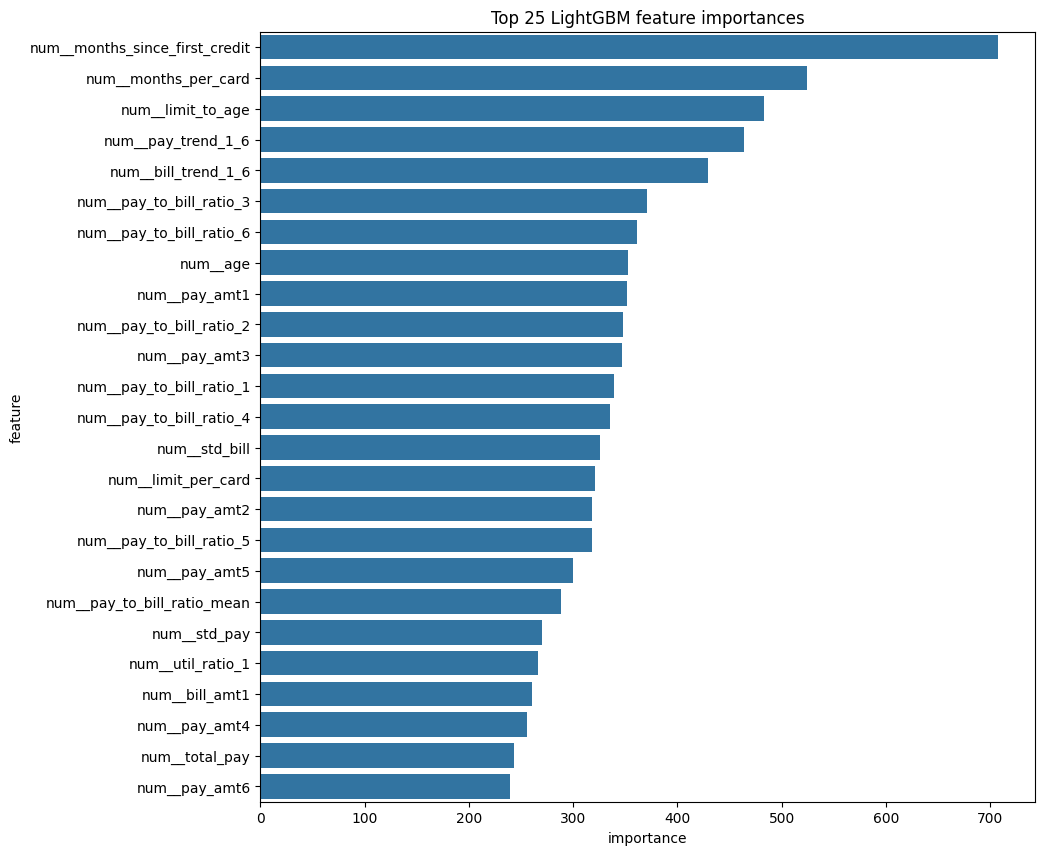

In [ ]:
if LGBMClassifier is not None:
    lgbm_inspect_pipe = Pipeline([
        ("prep", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ))
    ])

    lgbm_inspect_pipe.fit(X, y)

    feature_names = lgbm_inspect_pipe.named_steps["prep"].get_feature_names_out()
    importances = lgbm_inspect_pipe.named_steps["model"].feature_importances_

    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    display(imp_df.head(40))

    plt.figure(figsize=(10, 10))
    sns.barplot(data=imp_df.head(25), x="importance", y="feature")
    plt.title("Top 25 LightGBM feature importances")
    plt.show()

In [ ]:
best_model_name = leaderboard.index[0]
print("Best model:", best_model_name)

Best model: LightGBM
